# Convolutional Neural Network - Pytorch 

The following libraries are required to run this module.

In [1]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

The CIFAR-10 dataset is loaded directly from torchvision. It is split into training set (50,000 images) and test set (10,000 images). Both sets contain 32x32 RGB images across 10 mutually exclusive classes.

In [3]:
train_df = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    download=True
)

test_df = torchvision.datasets.CIFAR10(
    root="data",
    train=False,
    download=True
)

train_df.data.shape, test_df.data.shape

c:\Users\renat\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


((50000, 32, 32, 3), (10000, 32, 32, 3))

Based on the dataset, each image in CIFAR-10 has the following dimensions:

In [4]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3

Images are converted from PIL fromat to tensors. The same transform is applied to both the training and test sets.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_df.transform = transform
test_df.transform = transform

Let's display some sample images from the training set with their class labels. This step was generated by AI because is out of the scope of the main task.

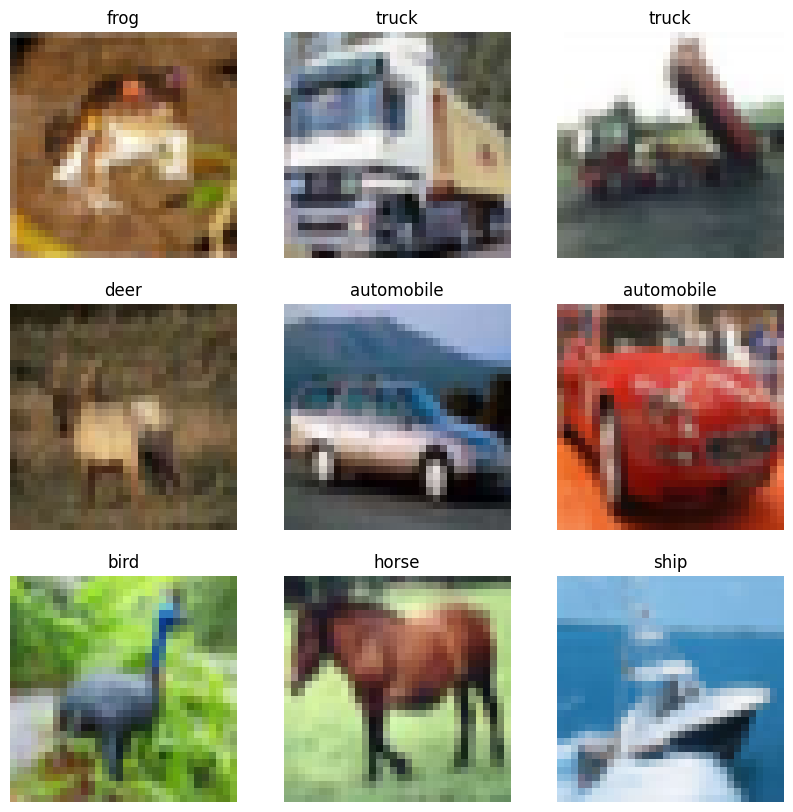

In [6]:
# Generated by AI
class_names = train_df.classes
images, labels = train_df.data[:9], train_df.targets[:9]

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

We need to create dataloaders for our training and test datasets. Dataloaders will allow us to load our data in batches, which is essential for training our model efficiently. We will use a batch size of 32 for both the training and test dataloaders.

In [21]:
batch_size = 32
train_dataloader = DataLoader(train_df, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_df, batch_size=batch_size, shuffle=False)

Now, let's define the training and testing loops. The following functions are the same as seen in class.

In [8]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [9]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        test_loss = 0.0
        test_acc = 0.0
        with torch.no_grad():
            for X_test, y_test in _test_loader:
                test_outputs = _model(X_test)
                test_loss += _criterion(test_outputs, y_test).item() * X_test.size(0)
                test_acc += get_batch_accuracy(test_outputs, y_test, len(_test_loader.dataset))

        epoch_test_loss = test_loss / len(_test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{test_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(test_acc)

    return res

In [10]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

### First Convolutional Neural Network

Now, we have our data in the form of tensors, we can start building a model. Let's create a simple convolutional neural network (CNN) using PyTorch's `nn.Module`.

In [23]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Dropout(.3),       
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(64, 64, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(64 * 4 * 4, 256), 
    nn.Dropout(.5),           
    nn.ReLU(),
    nn.Linear(256, 10)
)

model_cnn = model_cnn.to(device)

Then, we need to define a loss function and an optimizer for training the model. We will use `CrossEntropyLoss` as the loss function and Adam as the optimizer. Also, we will set the number of epochs for training the model. `CrossEntropyLoss` is selected because CIFAR-10 is a multiclass classification problem. 

In [22]:
epochs = 15
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)
loss_fn = nn.CrossEntropyLoss()

We traine the model.

In [24]:
cnn_res = train(model_cnn, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Training: 100%|██████████| 15/15 [11:01<00:00, 44.08s/epoch, test_acc=0.0725, test_loss=2.3037, train_acc=0.0930, train_loss=2.3038]


The following graph shows the learning curves for train and test loss accros epochs.

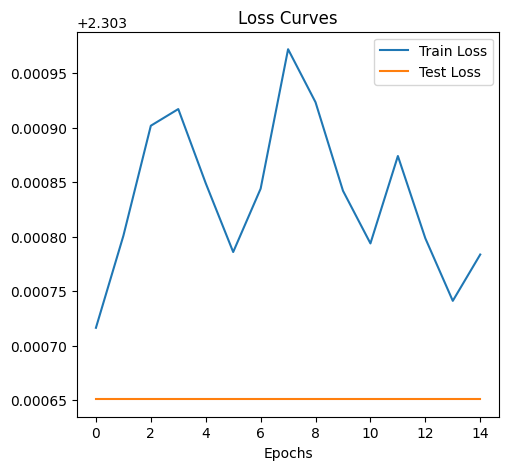

In [25]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['test_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.legend()
plt.show()

### Second CNN

In [15]:
model_cnn_2 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1), # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), # 25 x 16 x 16
    nn.Conv2d(25, 50, 3, stride=1, padding=1), # 50 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2), # 50 x 8 x 8
    nn.Conv2d(50, 75, 3, stride=1, padding=1), # 75 x 8 x 8
    nn.ReLU(),  
    nn.MaxPool2d(2, stride=2), # 75 x 4 x 4
    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10)
)

model_cnn_2 = model_cnn_2.to(device)

In [16]:
cnn_res_2 = train(model_cnn_2, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Training:   0%|          | 0/20 [00:10<?, ?epoch/s]


KeyboardInterrupt: 

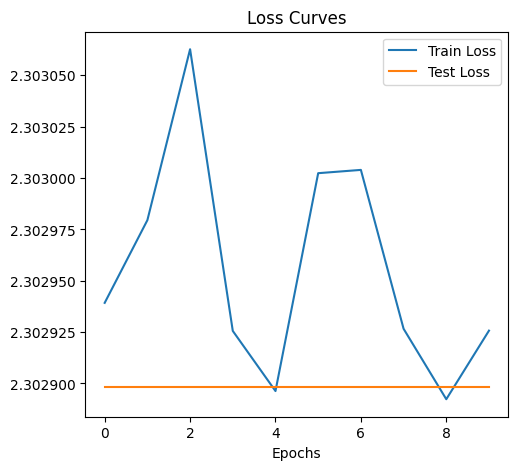

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_res_2['train_loss'], label='Train Loss')
plt.plot(cnn_res_2['test_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.legend()
plt.show()

### Third Model

In [ ]:
model_cnn_3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1), # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), # 25 x 16 x 16
    nn.Conv2d(25, 50, 3, stride=1, padding=1), # 50 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2), # 50 x 8 x 8
    nn.Conv2d(50, 75, 3, stride=1, padding=1), # 75 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), # 75 x 4 x 4
    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10)
)

model_cnn_3 = model_cnn_3.to(device)

In [ ]:
cnn_res_3 = train(model_cnn_3, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Training: 100%|██████████| 10/10 [05:33<00:00, 33.31s/epoch, test_acc=0.1000, test_loss=2.3031, train_acc=0.0996, train_loss=2.3032]


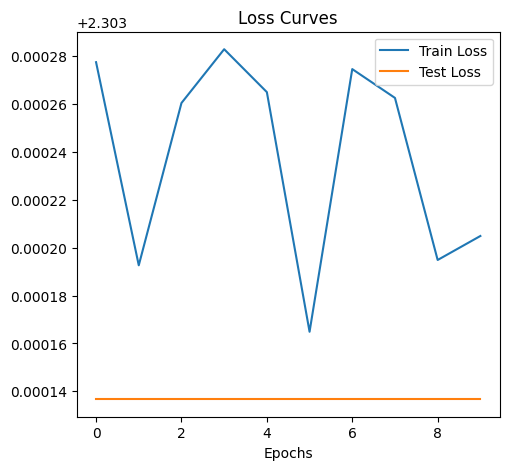

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_res_3['train_loss'], label='Train Loss')
plt.plot(cnn_res_3['test_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.legend()
plt.show()

Evaluate the models on the test set and compare their performance.


In [ ]:
models = [model_cnn, model_cnn_2, model_cnn_3]
results = []
for model in models:
    test_loss, test_acc = test(model, test_dataloader, loss_fn)
    results.append((test_loss, test_acc))

print("Model Performance:")
for i, (loss, acc) in enumerate(results):
    print(f"Model {i+1}: Test Loss = {loss:.4f}, Test Accuracy = {acc:.4f}")

Model Performance:
Model 1: Test Loss = 0.7978, Test Accuracy = 0.7270
Model 2: Test Loss = 2.3029, Test Accuracy = 0.1086
Model 3: Test Loss = 2.3031, Test Accuracy = 0.1000
